In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
%matplotlib widget

In [2]:
df = pd.read_csv('../Datasets/scrap price.csv')

In [3]:
df.head()

,ID,symboling,name,fueltypes,aspiration,doornumbers,carbody,drivewheels,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   name              205 non-null    object 
 3   fueltypes         205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumbers       205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheels       205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

In [5]:
df.isnull().sum()

ID                  0
symboling           0
name                0
fueltypes           0
aspiration          0
doornumbers         0
carbody             0
drivewheels         0
enginelocation      0
wheelbase           0
carlength           0
carwidth            0
carheight           0
curbweight          0
enginetype          0
cylindernumber      0
enginesize          0
fuelsystem          0
boreratio           0
stroke              0
compressionratio    0
horsepower          0
peakrpm             0
citympg             0
highwaympg          0
price               0
dtype: int64

In [6]:
df.isna().sum()

ID                  0
symboling           0
name                0
fueltypes           0
aspiration          0
doornumbers         0
carbody             0
drivewheels         0
enginelocation      0
wheelbase           0
carlength           0
carwidth            0
carheight           0
curbweight          0
enginetype          0
cylindernumber      0
enginesize          0
fuelsystem          0
boreratio           0
stroke              0
compressionratio    0
horsepower          0
peakrpm             0
citympg             0
highwaympg          0
price               0
dtype: int64

In [7]:
x = df[["enginesize", "horsepower"]].values
x.shape

(205, 2)

In [8]:
y = df['price'].to_numpy()
y = y.reshape(len(y), 1)
y.shape

(205, 1)

In [9]:
## Z-score estandarización o normalización
m = np.mean(x, axis=0)
std = np.std(x, axis=0)
x = (x - m) / std

# print("Media:", np.mean(x))
# print("Std:", np.std(x))

In [10]:
arry_unos = np.ones((x.shape[0], 1))

x1 = x[:, 0].reshape(-1, 1)
x2 = x[:, 1].reshape(-1, 1)

x = np.concatenate((arry_unos, x1, x2, x1**2, x2**2, x1 * x2), axis=1)
# X_b=np.c_[np.ones((len(x),1)),x[:,0],x[:,1],x[:,0]**2,x[:,0]*x[:,1],x[:,1]**2]

print(x.shape)
print(x)
# print(2.45454545e+0 ** 2)

(205, 6)
[[1.         0.07444893 0.17448278 0.00554264 0.03044424 0.01299006]
 [1.         0.07444893 0.17448278 0.00554264 0.03044424 0.01299006]
 [1.         0.60404617 1.26453643 0.36487177 1.59905238 0.76383838]
 ...
 [1.         1.10957081 0.75753473 1.23114738 0.57385887 0.84053842]
 [1.         0.43553795 0.04773235 0.18969331 0.00227838 0.02078925]
 [1.         0.33924755 0.25053303 0.1150889  0.0627668  0.08499272]]


In [11]:
print(x.shape)
print(y.shape)

(205, 6)
(205, 1)


In [12]:
theta = np.zeros((6, 1))
loss = np.zeros((1000))
lr = 1e-4 # learning rate

for i in range(1000):
    h = np.dot(x, theta) # Hipotesis 
    r = h - y # residuos
    grad = x.T@r # gradiente
    theta = theta - lr*grad # actualizacion de theta

    loss[i] = np.mean(r**2) # calculo del error

print(grad.shape)
print(theta)

(6, 1)
[[13127.82951497]
 [ 4669.57611687]
 [ 2511.19504054]
 [ 1275.29179432]
 [  750.76197578]
 [-2315.71247439]]


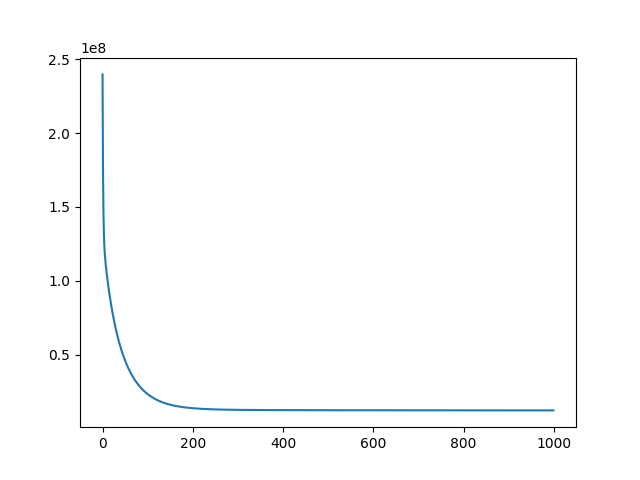

In [13]:
plt.plot(loss)
plt.show()

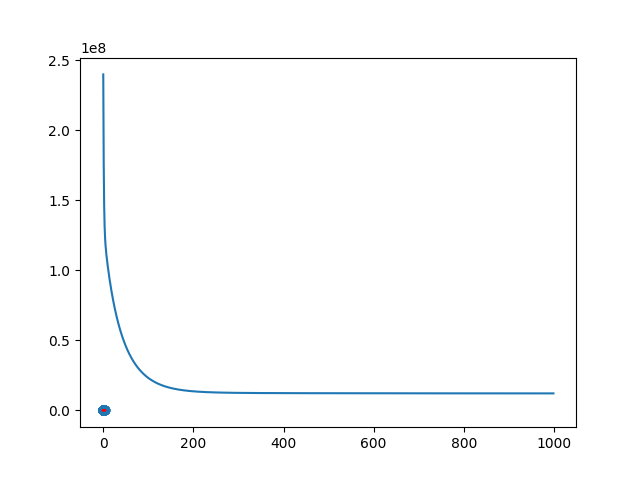

In [14]:
plt.scatter(x[:, 1], y)
plt.plot(x[:, 1], h, "r--")
plt.show()

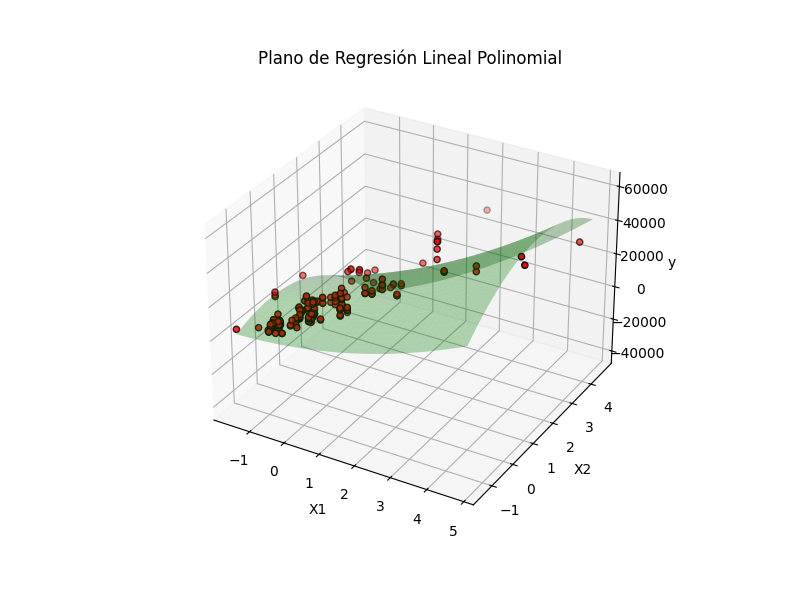

In [17]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(x[:,1], 
           x[:,2], 
           y[:,0], 
           color='red', 
           edgecolor='black'
)

# Crear malla
x1_range = np.linspace(x[:,1].min(), x[:,1].max(), 40)
x2_range = np.linspace(x[:,2].min(), x[:,2].max(), 40)

x1_surf, x2_surf = np.meshgrid(x1_range, x2_range)

theta_flat = theta.flatten()

# Plano de regresión
y_surf = theta_flat[0] + theta_flat[1]*x1_surf + theta_flat[2]*x2_surf + theta_flat[3]*x1_surf*x2_surf + theta_flat[4]*x1_surf**2 + theta_flat[5]*x2_surf**2

ax.plot_surface(x1_surf, x2_surf, y_surf, alpha=0.3, color='green')

ax.set_xlabel("X1")
ax.set_ylabel("X2")
ax.set_zlabel("y")
ax.set_title("Plano de Regresión Lineal Polinomial")

plt.show()